In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
startup=pd.read_csv('startup11.csv')

In [28]:
startup.head(5)

,state_code,latitude,longitude,zip_code,id,city,name,labels,founded_at,closed_at,...,milestones,category_code,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
0,CA,42.358880,-71.056820,92101,c:6669,San Diego,Bandsintown,1,2007-01-01,NaN,...,3,music,0,1,0,0,0,0,1.0000,0
1,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,TriCipher,1,2000-01-01,NaN,...,1,enterprise,1,0,0,1,1,1,4.7500,1
2,CA,32.901049,-117.192656,92121,c:65620,San Diego,Plixi,1,2009-03-18,NaN,...,2,web,0,0,1,0,0,0,4.0000,1
3,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Solidcore Systems,1,2002-01-01,NaN,...,1,software,0,0,0,1,1,1,3.3333,1
4,CA,37.779281,-122.419236,94105,c:65806,San Francisco,Inhale Digital,0,2010-08-01,2012-10-01,...,1,games_video,1,1,0,0,0,0,1.0000,1


In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import StratifiedKFold,cross_val_score

In [30]:
startup1=startup.copy()

In [31]:
removed=['zip_code', 'id', 'city', 'name',
    'founded_at', 'closed_at', 'first_funding_at', 'last_funding_at','is_top500'
]


In [32]:
startup1=startup1.drop(columns=removed)


In [33]:
startup1.columns.str.strip()

Index(['state_code', 'latitude', 'longitude', 'labels',
       'age_first_funding_year', 'age_last_funding_year',
       'age_first_milestone_year', 'age_last_milestone_year', 'relationships',
       'funding_rounds', 'funding_total_usd', 'milestones', 'category_code',
       'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC',
       'has_roundD', 'avg_participants'],
      dtype='object')

In [34]:
startup1['state_code']=startup1['state_code'].astype('category')
startup1['category_code']=startup1['category_code'].astype('category')

MODELING STARTS HERE

decide x and y and split the data

In [35]:
#We have only 20 columns types (category,int,float)
y=startup1['labels']
X=startup1[[col for col in startup1.columns if col!='labels']]

In [36]:
X_train, X_test, y_train, y_test= train_test_split( X, y, test_size=0.3, random_state=42, stratify=y)

Logistic Regression

In [37]:
from sklearn.preprocessing import StandardScaler
#Evaluation
from sklearn.metrics import classification_report, roc_auc_score, f1_score

In [38]:
scaler=StandardScaler()
num_cols=[
 'latitude',
 'longitude',
 'age_first_funding_year',
 'age_last_funding_year',
 'age_first_milestone_year',
 'age_last_milestone_year',
 'funding_total_usd',
 'avg_participants']

In [42]:
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [43]:
cat_cols=['state_code','category_code']
X_train_encoded=pd.get_dummies(X_train,columns=cat_cols, drop_first=True)
X_test_encoded=pd.get_dummies(X_test,columns=cat_cols, drop_first=True)

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
#add class_weighed='balance' as parameter to test for balanced model and to that for RF too.
logreg=LogisticRegression(max_iter=1000, random_state=42)


In [46]:
logreg.fit(X_train_encoded, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [47]:
y_pred=logreg.predict(X_test_encoded)
y_pred_prob=logreg.predict_proba(X_test_encoded)[:,1]


In [48]:
LRroc_auc=roc_auc_score(y_test, y_pred_prob)
LRroc_auc

0.8054383764679056

In [55]:
from sklearn.metrics import f1_score,accuracy_score

In [50]:
LRf1=f1_score(y_test, y_pred)
LRf1

0.807799442896936

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.64      0.65        98
           1       0.81      0.81      0.81       179

    accuracy                           0.75       277
   macro avg       0.73      0.73      0.73       277
weighted avg       0.75      0.75      0.75       277



Strafied

In [52]:

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
roc_auc_scores=cross_val_score(logreg, X_train_encoded, y_train, cv=skf, scoring='roc_auc')
f1_scores=cross_val_score(logreg, X_train_encoded, y_train, cv=skf, scoring='f1')
print("Roc_auc CV scores:", roc_auc_scores)
print("mean roc_auc:",  roc_auc_scores.mean())
print("f1 cv scores:", f1_scores)
print("mean f1 cv score:", f1_scores.mean())

Roc_auc CV scores: [0.79089027 0.76558408 0.79256155 0.77698413 0.80687831]
mean roc_auc: 0.7865796657991525
f1 cv scores: [0.83146067 0.77906977 0.79761905 0.83977901 0.8372093 ]
mean f1 cv score: 0.8170275594137311


optimal regularization strength(C) for hyperparameter tuning

CV fir hyperparameter tuning

In [53]:

from sklearn.model_selection import GridSearchCV
param_grid={'C' : [0.01,0.1,1,10,100], 'penalty':['l2'], 'solver':['lbfgs']}
grid=GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train_encoded, y_train)
best_model=grid.best_estimator_
print(grid.best_params_)

{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [56]:
# Predictions
y_pred_log = best_model.predict(X_test_encoded)
y_pred_prob_log = best_model.predict_proba(X_test_encoded)[:, 1]

# Metrics
roc_auc_log = roc_auc_score(y_test, y_pred_prob_log)
f1_log = f1_score(y_test, y_pred_log)
accuracy_log = accuracy_score(y_test, y_pred_log)

print("ROC-AUC:", roc_auc_log)
print("F1-score:", f1_log)
print("Accuracy:", accuracy_log)

ROC-AUC: 0.8054383764679056
F1-score: 0.807799442896936
Accuracy: 0.7509025270758123


In [57]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for LR
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_log).ravel()

# Sensitivity (TPR, Recall)
sensitivity_log = tp / (tp + fn)

# Specificity (TNR)
specificity_log = tn / (tn + fp)

print("Sensitivity:", sensitivity_log)
print("Specificity:", specificity_log)

Sensitivity: 0.8100558659217877
Specificity: 0.6428571428571429


FEATURE IMPORTANCE

In [58]:
coeffs=pd.DataFrame({'features':  X_train_encoded.columns, 'coef':logreg.coef_[0]})
coeffs['abs_coef']=coeffs['coef'].abs()
coeffs.sort_values('abs_coef', ascending=False)
coeffs['Effect']=coeffs['coef'].apply(lambda x: 'Positive' if x>0 else 'Negative' )

In [62]:
coeffs.sort_values('abs_coef', ascending=False).head(20)

,features,coef,abs_coef,Effect
34,state_code_NC,-1.618785,1.618785,Negative
72,category_code_other,-1.308088,1.308088,Negative
78,category_code_semiconductor,1.130579,1.130579,Positive
20,state_code_CT,-0.985600,0.985600,Negative
74,category_code_public_relations,-0.906069,0.906069,Negative
15,has_roundD,0.881972,0.881972,Positive
28,state_code_MA,0.837809,0.837809,Positive
62,category_code_hardware,-0.835511,0.835511,Negative
41,state_code_OR,0.779153,0.779153,Positive
71,category_code_news,0.681936,0.681936,Positive


In [60]:
import seaborn as sns

/Users/smyy.karaalioglu/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


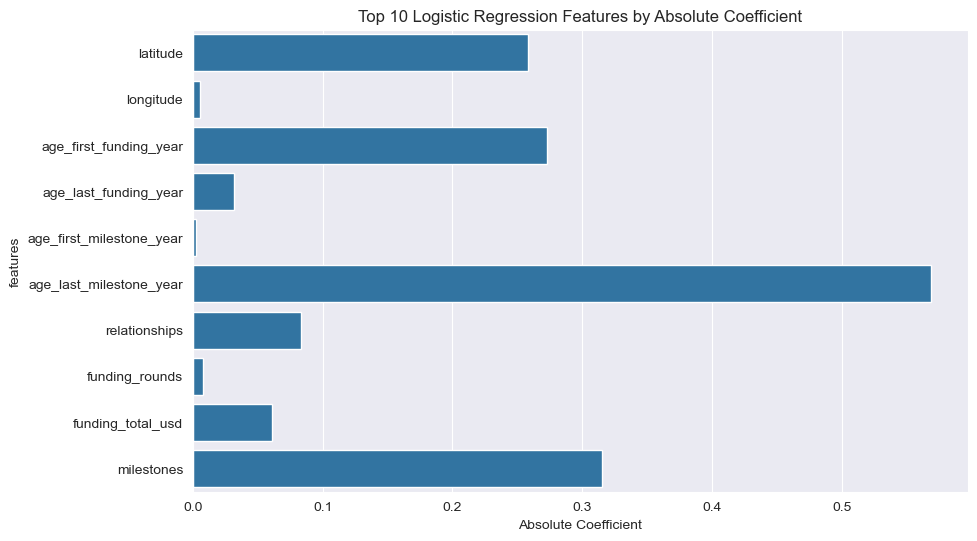

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(x='abs_coef', y='features', data=coeffs.head(10))   #, hue='Effect', dodge=False)
plt.title('Top 10 Logistic Regression Features by Absolute Coefficient')
plt.xlabel('Absolute Coefficient')

plt.show()


RANDOM FOREST
train-tune-evaluate

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
from sklearn.preprocessing import LabelEncoder
X_rf=X.copy()
for col in ['state_code','category_code']:
    le=LabelEncoder()
    X_rf[col]=le.fit_transform(X_rf[col])

In [39]:
le_state=LabelEncoder()
le_category = LabelEncoder()
X_train['state_code']=le_state.fit_transform(X_train['state_code'])
X_test['state_code']=le_state.fit_transform(X_test['state_code'])
X_train['category_code']=le_category.fit_transform(X_train['category_code'])
X_test['category_code']=le_category.fit_transform(X_test['category_code'])

In [43]:
rf=RandomForestClassifier( random_state=42)
rf.fit(X_train, y_train)
y_pred_rf=rf.predict(X_test)
y_pred_prob_rf=rf.predict_proba(X_test)[:,1]

Evaluation

In [44]:
rf_roc_auc=roc_auc_score(y_test, y_pred_prob_rf)
rf_f1=f1_score(y_test, y_pred_rf)
print("roc_auc:",rf_roc_auc)
print("f1:",rf_f1)
print(classification_report(y_test, y_pred_rf))

roc_auc: 0.8523543495610535
f1: 0.8802083333333334
              precision    recall  f1-score   support

           0       0.86      0.63      0.73        98
           1       0.82      0.94      0.88       179

    accuracy                           0.83       277
   macro avg       0.84      0.79      0.80       277
weighted avg       0.84      0.83      0.83       277



tune parameters for RF with RandomizedSearchCV

In [45]:
from sklearn.model_selection import RandomizedSearchCV

In [46]:
param_dist={
    'n_estimators':[100,200,300,400,500],
    'max_depth':[None, 5,10,15,20],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4,6],
    'max_features': ['sqrt','log2', None],
    'bootstrap': [True, False]
}

In [47]:
random_search=RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [48]:
random_search.fit(X_train, y_train)
print('best hyperparameters:', random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best hyperparameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}


In [49]:
best_rf=random_search.best_estimator_
y_pred_rf2=best_rf.predict(X_test)
y_pred_prob_rf2=best_rf.predict_proba(X_test)[:,1]
rf_roc_auc2=roc_auc_score(y_test, y_pred_prob_rf2)
rf_f12=f1_score(y_test, y_pred_rf2)
print('roc_auc:',rf_roc_auc2)
print('f1_score:', rf_f12)

roc_auc: 0.8610192680424125
f1_score: 0.8854166666666666


In [69]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_rf2)
print("accuracy:", accuracy)

accuracy: 0.8411552346570397


In [50]:
print(classification_report(y_test, y_pred_rf2))

              precision    recall  f1-score   support

           0       0.88      0.64      0.74        98
           1       0.83      0.95      0.89       179

    accuracy                           0.84       277
   macro avg       0.85      0.80      0.81       277
weighted avg       0.85      0.84      0.83       277



In [84]:

# Predictions at threshold = 0.5
y_pred_class = (y_pred_prob_rf2 >= 0.5).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_class).ravel()

# Sensitivity (Recall, TPR)
sensitivity = tp / (tp + fn)

# Specificity (TNR)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Sensitivity: 0.9497206703910615
Specificity: 0.6428571428571429


Feature importance for RF

In [72]:
importances=best_rf.feature_importances_
feature_names=X_train.columns


In [73]:
feat_imp_df=pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

In [78]:
feat_imp_df=feat_imp_df.sort_values(by='importance', ascending=False)
print(feat_imp_df.head(5))


                     feature  importance
6    age_last_milestone_year    0.205423
7              relationships    0.148201
5   age_first_milestone_year    0.135168
10                milestones    0.092890
9          funding_total_usd    0.083358


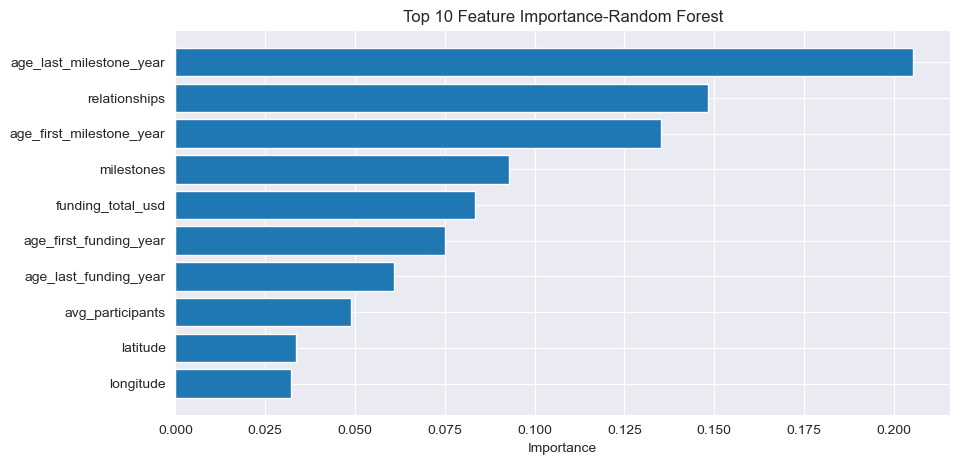

In [75]:
plt.figure(figsize=(10,5))
plt.barh(feat_imp_df['feature'][:10][::-1], feat_imp_df['importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance-Random Forest')
plt.show()

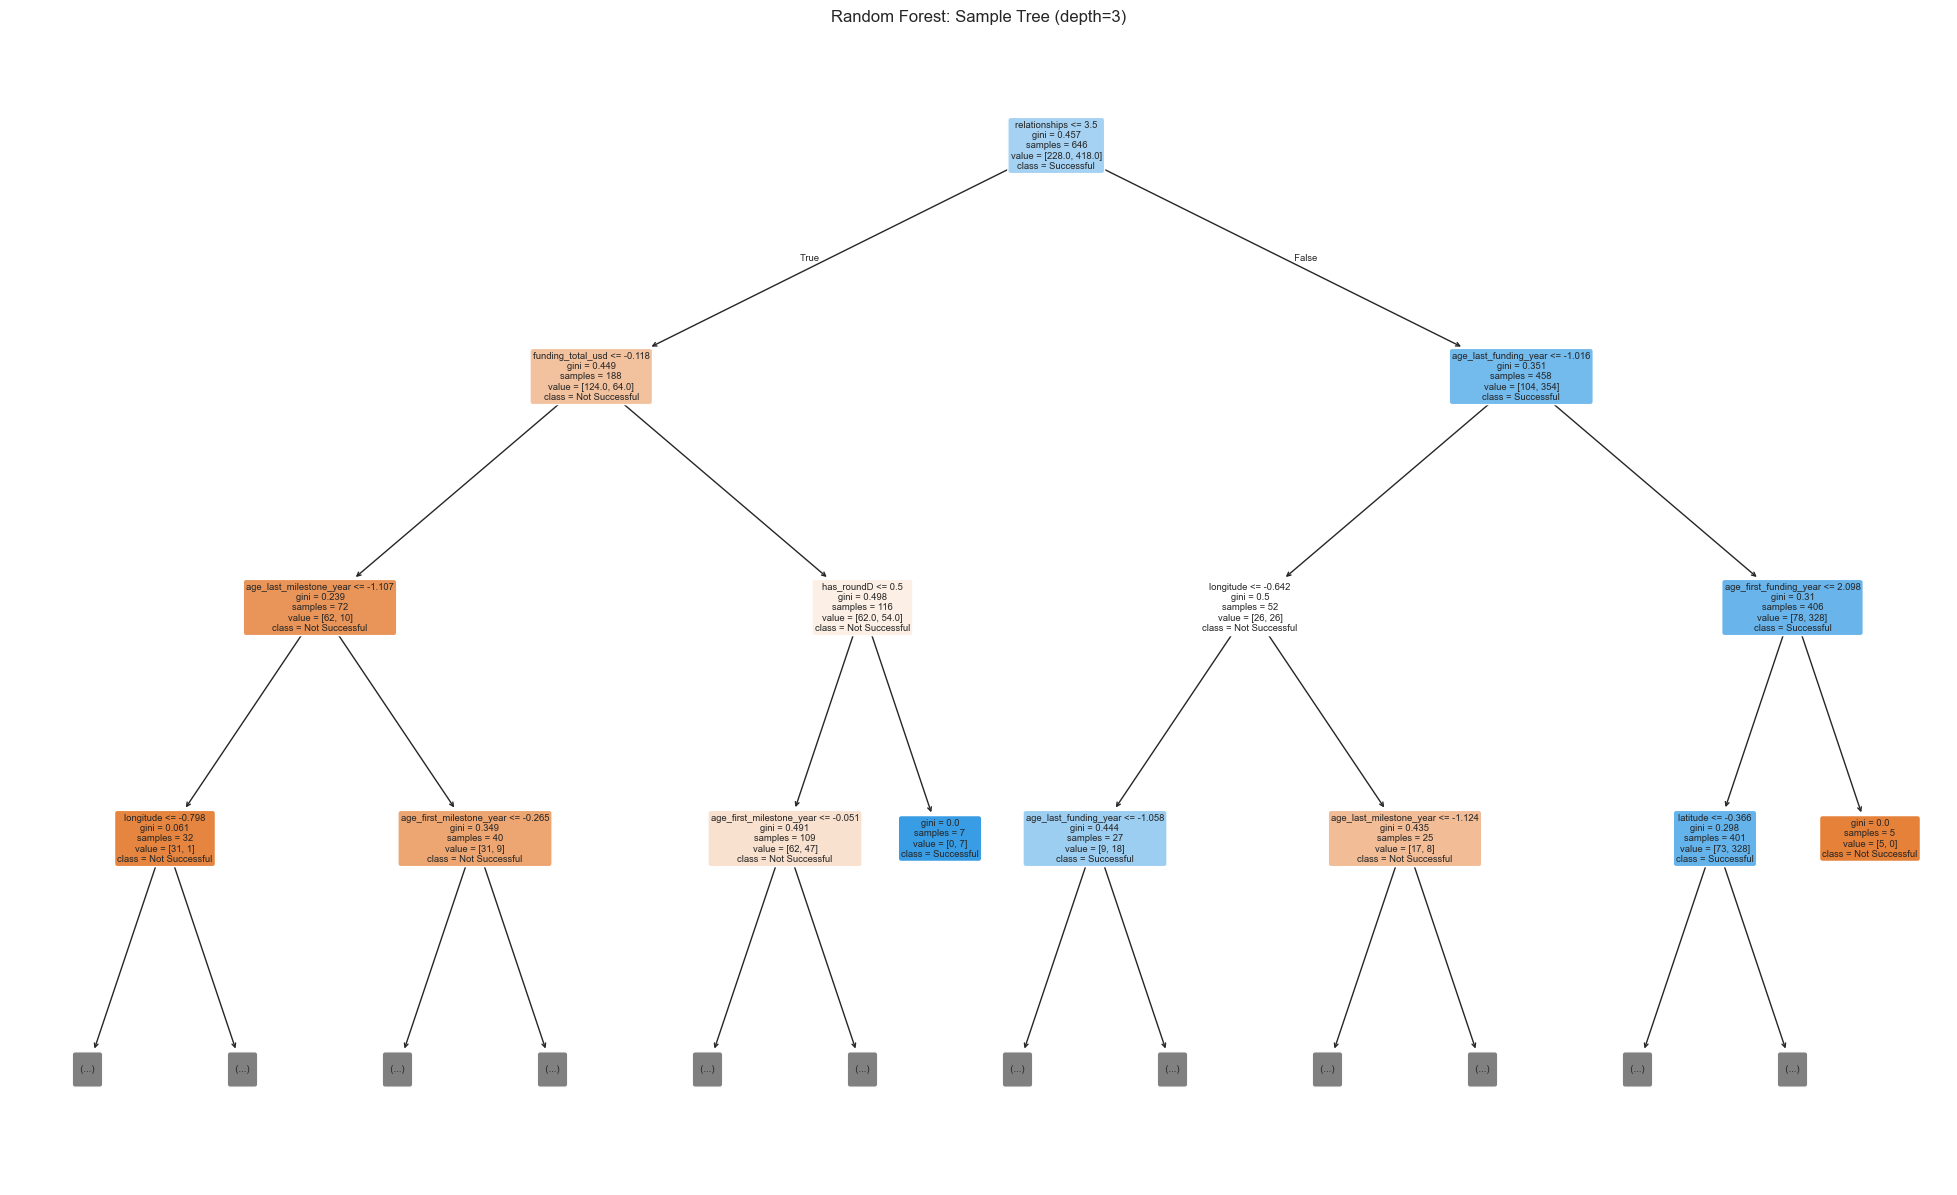

In [79]:
from sklearn.tree import plot_tree
estimator=best_rf.estimators_[3] #pick one tree


plt.figure(figsize=(25,15))
plot_tree(estimator,
          feature_names=X_train.columns,
          class_names=['Not Successful', 'Successful'],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title('Random Forest: Sample Tree (depth=3)')
plt.show()

In [131]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [135]:
estimators=[
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
]

In [136]:
stack_model=StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stack_model.fit(X_train, y_train)
y_pred_stack=stack_model.predict(X_test)
y_pred_prob_stack=stack_model.predict_proba(X_test)[:,1]

In [137]:
from sklearn.ensemble import VotingClassifier

In [140]:
vote_model=VotingClassifier(
    estimators=[
        ('lr', logreg),
        ('rf', rf)
    ],
    voting='soft'
)
vote_model.fit(X_train, y_train)
y_pred_vote=vote_model.predict(X_test)
y_pred_prob_vote=vote_model.predict_proba(X_test)[:,1]

In [141]:
S_roc_auc=roc_auc_score(y_test, y_pred_prob_stack)
Srf_f1=f1_score(y_test, y_pred_stack)
print("roc_auc:",S_roc_auc)
print("f1:",Srf_f1)
print(classification_report(y_test, y_pred_stack))

roc_auc: 0.8463687150837989
f1: 0.8677248677248677
              precision    recall  f1-score   support

           0       0.81      0.64      0.72        98
           1       0.82      0.92      0.87       179

    accuracy                           0.82       277
   macro avg       0.82      0.78      0.79       277
weighted avg       0.82      0.82      0.81       277



In [142]:
V_roc_auc=roc_auc_score(y_test, y_pred_prob_vote)
Vrf_f1=f1_score(y_test, y_pred_vote)
print("roc_auc:",V_roc_auc)
print("f1:",Vrf_f1)
print(classification_report(y_test, y_pred_vote))

roc_auc: 0.8497890776422301
f1: 0.83008356545961
              precision    recall  f1-score   support

           0       0.69      0.68      0.69        98
           1       0.83      0.83      0.83       179

    accuracy                           0.78       277
   macro avg       0.76      0.76      0.76       277
weighted avg       0.78      0.78      0.78       277

